# Integrated Industrial Disaster Simulation

## Bhopal Gas Tragedy – Scenario-Based Hazard, Exposure and Evacuation Analysis

### Objective

This project develops an integrated simulation framework to analyze how a toxic industrial gas release propagates through a population and how emergency interventions such as faster alarms and evacuation can reduce population exposure and risk.

### Simulation Pipeline

Accident Initiation → Gas Release → Atmospheric Dispersion → Population Exposure → Evacuation → Risk Assessment → Scenario Comparison

In [7]:
import numpy as np

print(np.__version__)

2.4.6


In [8]:
# ============================================================
# MODULE 1: SIMULATION CONFIGURATION
# Integrated Industrial Disaster Simulation
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# ------------------------------------------------------------
# 1. INDUSTRIAL ACCIDENT SCENARIO
# ------------------------------------------------------------

scenario = {
    
    # Gas release
    "released_mass_kg": 40000,
    "release_duration_min": 60,
    
    # Atmospheric conditions
    "wind_speed_mps": 1.5,
    
    # Simulation geography
    "city_length_m": 5000,
    "city_width_m": 3000,
    
    # Population
    "population_size": 1000,
    
    # Simulation time
    "simulation_duration_min": 180,
    "time_step_min": 1
}

scenario

{'released_mass_kg': 40000,
 'release_duration_min': 60,
 'wind_speed_mps': 1.5,
 'city_length_m': 5000,
 'city_width_m': 3000,
 'population_size': 1000,
 'simulation_duration_min': 180,
 'time_step_min': 1}

In [9]:
# ============================================================
# MODULE 1: SIMULATION CONFIGURATION
# Integrated Industrial Disaster Simulation
# ============================================================

config = {
    "released_mass_kg": 40000,
    "release_duration_min": 60,
    "wind_speed_mps": 1.5,
    "city_length_m": 5000,
    "city_width_m": 3000,
    "population_size": 1000,
    "simulation_duration_min": 180,
    "time_step_min": 1
}

config

{'released_mass_kg': 40000,
 'release_duration_min': 60,
 'wind_speed_mps': 1.5,
 'city_length_m': 5000,
 'city_width_m': 3000,
 'population_size': 1000,
 'simulation_duration_min': 180,
 'time_step_min': 1}

# Module 1: Simulation Configuration

This module defines the baseline assumptions and parameters for the
integrated industrial disaster simulation.

The parameters control:

- MIC release characteristics
- Meteorological conditions
- Spatial dimensions of the affected city
- Population size
- Simulation horizon
- Temporal resolution

All subsequent modules use this configuration as the central simulation input.

# Module 2: Spatial Environment and Population Generation

This module creates a simplified spatial representation of the affected city
and generates population agents across the simulation area.

Each population agent represents an individual with:

- Spatial location
- Movement characteristics
- Exposure history
- Health risk status

The population distribution will later be combined with the gas dispersion
model to estimate individual and population-level exposure.

In [10]:
# ============================================================
# MODULE 2: SPATIAL ENVIRONMENT & POPULATION GENERATION
# Integrated Industrial Disaster Simulation
# ============================================================

# Set random seed for reproducibility
np.random.seed(42)

# Extract city dimensions from configuration
city_length = config["city_length_m"]
city_width = config["city_width_m"]
population_size = config["population_size"]

# ------------------------------------------------------------
# Define Industrial Accident Source Location
# ------------------------------------------------------------

source_x = 0
source_y = city_width / 2

# ------------------------------------------------------------
# Generate Population Agents
# ------------------------------------------------------------

population = pd.DataFrame({
    "agent_id": np.arange(population_size),

    # Initial spatial coordinates
    "x_position_m": np.random.uniform(
        0, city_length, population_size
    ),

    "y_position_m": np.random.uniform(
        0, city_width, population_size
    ),

    # Individual evacuation speed (m/min)
    "walking_speed_m_min": np.random.normal(
        loc=70,
        scale=15,
        size=population_size
    )
})

# Ensure realistic positive movement speeds
population["walking_speed_m_min"] = population[
    "walking_speed_m_min"
].clip(lower=30, upper=120)

# ------------------------------------------------------------
# Initialize Simulation Variables
# ------------------------------------------------------------

population["aware"] = False
population["exposure_dose"] = 0.0
population["risk_level"] = "Not Assessed"
population["evacuated"] = False

# Display first few agents
population.head()

,agent_id,x_position_m,y_position_m,walking_speed_m_min,aware,exposure_dose,risk_level,evacuated
0,0,1872.700594,555.398787,56.830261,False,0.0,Not Assessed,False
1,1,4753.571532,1625.702842,57.596795,False,0.0,Not Assessed,False
2,2,3659.969709,2618.837508,66.602817,False,0.0,Not Assessed,False
3,3,2993.292421,2196.674659,75.510483,False,0.0,Not Assessed,False
4,4,780.093202,2419.683444,83.703769,False,0.0,Not Assessed,False


# Module 3: Simplified MIC Dispersion and Hazard Field

This module models the downwind transport and crosswind dispersion of the
released toxic gas.

A simplified Gaussian dispersion framework is used to estimate relative gas
concentration across the simulated city.

The model incorporates:

- Release rate
- Wind transport
- Downwind distance
- Crosswind dispersion
- Time-dependent release duration

The resulting hazard field will be integrated with the population agents to
calculate individual exposure.

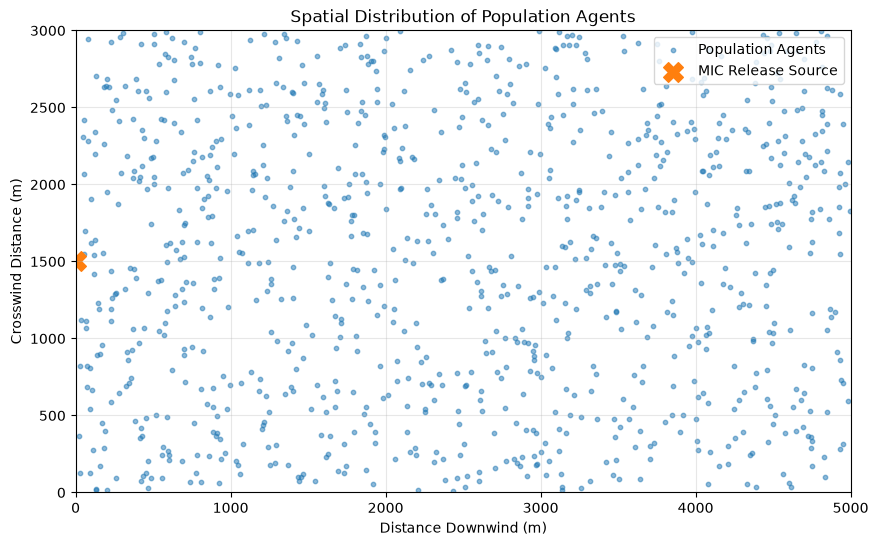

In [11]:
# ------------------------------------------------------------
# Visualize Spatial Environment
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    population["x_position_m"],
    population["y_position_m"],
    s=10,
    alpha=0.5,
    label="Population Agents"
)

# Mark industrial accident source
plt.scatter(
    source_x,
    source_y,
    s=200,
    marker="X",
    label="MIC Release Source"
)

plt.xlabel("Distance Downwind (m)")
plt.ylabel("Crosswind Distance (m)")
plt.title("Spatial Distribution of Population Agents")

plt.xlim(0, city_length)
plt.ylim(0, city_width)

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

In [12]:
# ============================================================
# MODULE 3: MIC DISPERSION & HAZARD FIELD
# Simplified Analytical Scenario Model
# ============================================================

# Extract simulation parameters
released_mass_kg = config["released_mass_kg"]
release_duration_min = config["release_duration_min"]
wind_speed_mps = config["wind_speed_mps"]

# Convert release duration to seconds
release_duration_sec = release_duration_min * 60

# Average release rate (kg/s)
release_rate_kg_s = released_mass_kg / release_duration_sec

# Convert population coordinates into
# downwind and crosswind coordinates

x = population["x_position_m"].values
y = population["y_position_m"].values - source_y

print(f"Average release rate: {release_rate_kg_s:.2f} kg/s")
print(f"Wind speed: {wind_speed_mps:.2f} m/s")

Average release rate: 11.11 kg/s
Wind speed: 1.50 m/s


In [13]:
# ------------------------------------------------------------
# Simplified Dispersion Parameters
# ------------------------------------------------------------

def sigma_y(x):
    """
    Crosswind dispersion parameter.
    Simplified representation for scenario analysis.
    """
    x_safe = np.maximum(x, 1)

    return 0.12 * x_safe


def sigma_z(x):
    """
    Vertical dispersion parameter.
    Simplified representation for scenario analysis.
    """
    x_safe = np.maximum(x, 1)

    return 0.08 * x_safe

In [14]:
def gas_concentration(x, y, time_min):
    """
    Estimate simplified gas concentration at population locations.

    Parameters
    ----------
    x : array
        Downwind distance from source (m)

    y : array
        Crosswind distance from plume centerline (m)

    time_min : float
        Simulation time in minutes

    Returns
    -------
    concentration : array
        Relative concentration field
    """

    # Initialize concentration
    concentration = np.zeros_like(x, dtype=float)

    # Gas only released during release period
    if time_min > release_duration_min:
        return concentration

    # Gas travel distance based on wind speed
    gas_front_distance = (
        wind_speed_mps
        * time_min
        * 60
    )

    # Locations reached by gas
    reached = x <= gas_front_distance

    if np.any(reached):

        sy = sigma_y(x[reached])
        sz = sigma_z(x[reached])

        # Simplified Gaussian concentration model
        concentration[reached] = (
            release_rate_kg_s
            /
            (
                2
                * np.pi
                * wind_speed_mps
                * sy
                * sz
            )
            *
            np.exp(
                -0.5
                * (y[reached] / sy) ** 2
            )
        )

    return concentration

In [15]:
# ------------------------------------------------------------
# Test Gas Concentration at 30 Minutes
# ------------------------------------------------------------

test_time = 30

concentration = gas_concentration(
    x,
    y,
    test_time
)

population["gas_concentration"] = concentration

print(
    f"Maximum concentration: "
    f"{concentration.max():.6f}"
)

print(
    f"Population exposed at {test_time} minutes: "
    f"{np.sum(concentration > 0)} agents"
)

Maximum concentration: 0.000631
Population exposed at 30 minutes: 512 agents


# MODULE 4: Population Exposure and Risk Assessment

This module integrates gas concentration over time for each population agent
to estimate cumulative exposure and classify individual risk levels.

In [16]:
# ============================================================
# RECREATE POPULATION AGENTS
# ============================================================

np.random.seed(42)

city_length = config["city_length_m"]
city_width = config["city_width_m"]
population_size = config["population_size"]

# Create population agents
agents = pd.DataFrame({
    "agent_id": range(population_size),

    # Downwind position
    "position_m": np.random.uniform(
        0, city_length, population_size
    ),

    # Crosswind position
    "crosswind_position_m": np.random.uniform(
        0, city_width, population_size
    ),

    # Individual walking speed
    "walking_speed_m_min": np.random.uniform(
        50, 90, population_size
    ),

    # Initial awareness
    "aware": False,

    # Exposure and risk
    "exposure_dose": 0.0,
    "risk_level": "Not Assessed",

    # Evacuation status
    "evacuated": False
})

print("Population agents created successfully.")
print(f"Total agents: {len(agents)}")

agents.head()

Population agents created successfully.
Total agents: 1000


,agent_id,position_m,crosswind_position_m,walking_speed_m_min,aware,exposure_dose,risk_level,evacuated
0,0,1872.700594,555.398787,60.468227,False,0.0,Not Assessed,False
1,1,4753.571532,1625.702842,59.879152,False,0.0,Not Assessed,False
2,2,3659.969709,2618.837508,86.250183,False,0.0,Not Assessed,False
3,3,2993.292421,2196.674659,59.981848,False,0.0,Not Assessed,False
4,4,780.093202,2419.683444,60.877989,False,0.0,Not Assessed,False


In [17]:
# ============================================================
# MODULE 4: POPULATION EXPOSURE AND RISK ASSESSMENT
# ============================================================

# Extract required parameters from configuration
wind_speed = config["wind_speed_mps"]
simulation_duration = config["simulation_duration_min"]
time_step = config["time_step_min"]

# Create a copy of population agents
simulation_agents = agents.copy()

# Initialize cumulative exposure
simulation_agents["exposure_dose"] = 0.0

# Simulation timeline
time_steps = np.arange(
    0,
    simulation_duration + time_step,
    time_step
)

# Store exposure statistics
exposure_history = []

print("Starting population exposure simulation...")

Starting population exposure simulation...


In [18]:
# ============================================================
# MODULE 4: TIME-BASED POPULATION EXPOSURE
# ============================================================

# Use the original population DataFrame consistently
simulation_agents = population.copy()

# Reset exposure
simulation_agents["exposure_dose"] = 0.0

# Coordinates relative to plume centerline
agent_x = simulation_agents["x_position_m"].values
agent_y = (
    simulation_agents["y_position_m"].values - source_y
)

# Simulation settings
simulation_duration = config["simulation_duration_min"]
time_step = config["time_step_min"]

time_steps = np.arange(
    0,
    simulation_duration + time_step,
    time_step
)

# Store simulation history
exposure_history = []

print("Starting integrated exposure simulation...")

for t in time_steps:

    # Use Module 3 concentration function
    concentration = gas_concentration(
        agent_x,
        agent_y,
        t
    )

    # Accumulate concentration-time exposure
    simulation_agents["exposure_dose"] += (
        concentration * time_step
    )

    # Store statistics
    exposed = np.sum(concentration > 0)

    exposure_history.append({
        "time_min": t,
        "currently_exposed": exposed,
        "average_concentration": concentration.mean(),
        "max_concentration": concentration.max(),
        "average_cumulative_dose":
            simulation_agents["exposure_dose"].mean()
    })

print("Integrated exposure simulation completed successfully.")

Starting integrated exposure simulation...
Integrated exposure simulation completed successfully.


In [19]:
# ============================================================
# MODULE 4: INTEGRATED EXPOSURE RESULTS SUMMARY
# ============================================================

# Convert simulation history to DataFrame
exposure_history_df = pd.DataFrame(exposure_history)

# Total population that received any exposure
total_exposed = np.sum(
    simulation_agents["exposure_dose"] > 0
)

exposure_percentage = (
    total_exposed / len(simulation_agents)
) * 100


print("=" * 55)
print("INTEGRATED POPULATION EXPOSURE RESULTS")
print("=" * 55)

print(f"Total population: {len(simulation_agents)}")

print(
    f"Population with cumulative exposure: "
    f"{total_exposed}"
)

print(
    f"Exposure percentage: "
    f"{exposure_percentage:.2f}%"
)

print(
    f"Average cumulative exposure dose: "
    f"{simulation_agents['exposure_dose'].mean():.6f}"
)

print(
    f"Maximum cumulative exposure dose: "
    f"{simulation_agents['exposure_dose'].max():.6f}"
)

INTEGRATED POPULATION EXPOSURE RESULTS
Total population: 1000
Population with cumulative exposure: 964
Exposure percentage: 96.40%
Average cumulative exposure dose: 0.000329
Maximum cumulative exposure dose: 0.035991


# Module 5: Exposure-Based Risk Classification

This module converts cumulative population exposure into relative risk
categories.

The classification is based on the distribution of simulated cumulative
exposure rather than calibrated clinical toxicity thresholds.

Risk categories are used to compare emergency scenarios and evaluate
the effectiveness of safety interventions.

In [20]:
# ============================================================
# MODULE 5: EXPOSURE-BASED RISK CLASSIFICATION
# ============================================================

# Calculate exposure thresholds using population percentiles

low_threshold = simulation_agents["exposure_dose"].quantile(0.50)
moderate_threshold = simulation_agents["exposure_dose"].quantile(0.75)
high_threshold = simulation_agents["exposure_dose"].quantile(0.90)

print("EXPOSURE-BASED RISK THRESHOLDS")
print("-" * 45)

print(f"Low / Moderate threshold: {low_threshold:.6f}")
print(f"Moderate / High threshold: {moderate_threshold:.6f}")
print(f"High / Critical threshold: {high_threshold:.6f}")

EXPOSURE-BASED RISK THRESHOLDS
---------------------------------------------
Low / Moderate threshold: 0.000009
Moderate / High threshold: 0.000084
High / Critical threshold: 0.000370


In [21]:
def classify_risk(exposure):

    if exposure == 0:
        return "No Exposure"

    elif exposure <= low_threshold:
        return "Low Risk"

    elif exposure <= moderate_threshold:
        return "Moderate Risk"

    elif exposure <= high_threshold:
        return "High Risk"

    else:
        return "Critical Risk"

In [22]:
simulation_agents["risk_level"] = (
    simulation_agents["exposure_dose"]
    .apply(classify_risk)
)

# Count agents in each category
risk_summary = (
    simulation_agents["risk_level"]
    .value_counts()
)

print("RISK CLASSIFICATION SUMMARY")
print("=" * 45)

print(risk_summary)

RISK CLASSIFICATION SUMMARY
risk_level
Low Risk         464
Moderate Risk    250
High Risk        150
Critical Risk    100
No Exposure       36
Name: count, dtype: int64


# Module 6: Spatial Risk Visualization

This module visualizes the spatial distribution of population risk following
the simulated MIC release.

The map combines:

- Industrial release source
- Population locations
- Relative exposure-based risk categories
- Spatial distribution of high-risk areas

This visualization helps identify the population zones requiring the highest
priority for emergency intervention and evacuation.

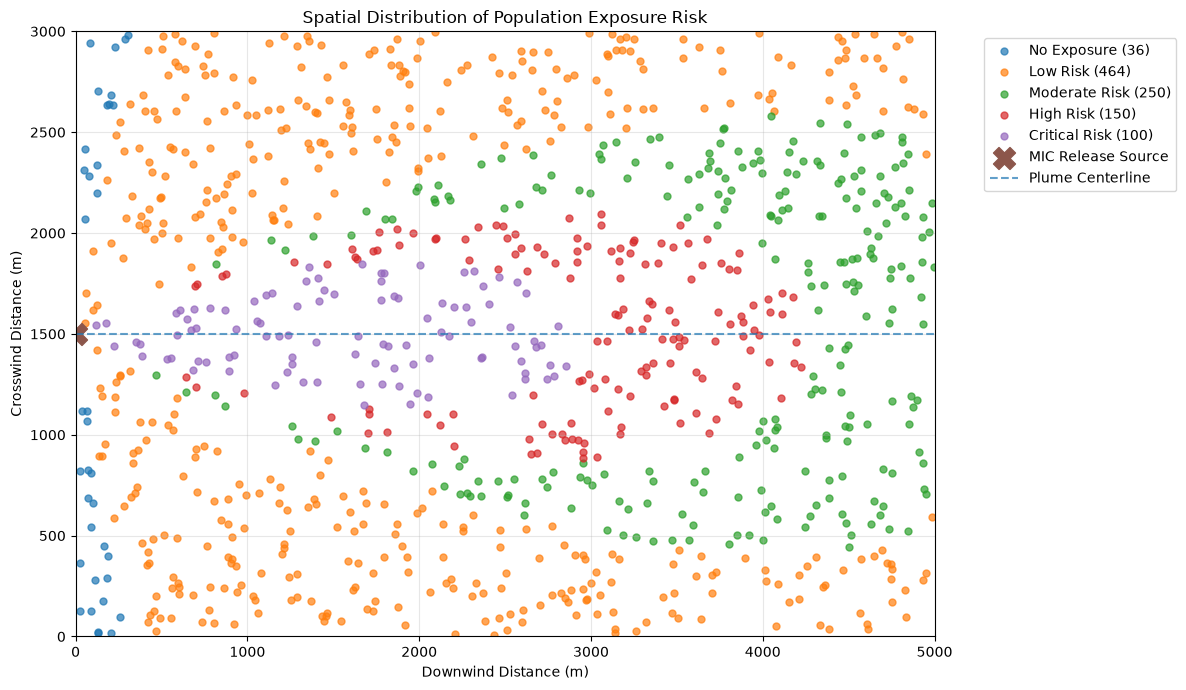

In [23]:
# ============================================================
# MODULE 6: SPATIAL RISK VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 7))

# Define plotting order
risk_order = [
    "No Exposure",
    "Low Risk",
    "Moderate Risk",
    "High Risk",
    "Critical Risk"
]

# Plot each risk category separately
for risk in risk_order:

    subset = simulation_agents[
        simulation_agents["risk_level"] == risk
    ]

    if len(subset) > 0:

        plt.scatter(
            subset["x_position_m"],
            subset["y_position_m"],
            s=25,
            alpha=0.7,
            label=f"{risk} ({len(subset)})"
        )

# ------------------------------------------------------------
# Plot MIC Release Source
# ------------------------------------------------------------

plt.scatter(
    source_x,
    source_y,
    s=250,
    marker="X",
    label="MIC Release Source"
)

# ------------------------------------------------------------
# Plot plume centerline
# ------------------------------------------------------------

plt.axhline(
    source_y,
    linestyle="--",
    alpha=0.7,
    label="Plume Centerline"
)

# ------------------------------------------------------------
# Labels and formatting
# ------------------------------------------------------------

plt.xlabel("Downwind Distance (m)")
plt.ylabel("Crosswind Distance (m)")

plt.title(
    "Spatial Distribution of Population Exposure Risk"
)

plt.xlim(0, city_length)
plt.ylim(0, city_width)

plt.grid(True, alpha=0.3)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

# Module 7: Dynamic Crosswind Evacuation Simulation

This module simulates population evacuation following the MIC release.

Unlike the baseline exposure simulation, agents can respond to an emergency
warning and move toward the nearest crosswind safe zone.

The evacuation strategy moves agents perpendicular to the dominant wind
direction, allowing them to leave the main gas plume more quickly.

The model evaluates how warning delays and evacuation speed influence
population exposure and risk.

In [24]:
# ============================================================
# MODULE 7: DYNAMIC CROSSWIND EVACUATION SIMULATION
# ============================================================

def simulate_evacuation(
    initial_agents,
    alarm_delay_min=20,
    evacuation_speed_factor=1.0
):
    
    # --------------------------------------------------------
    # Create independent copy of population
    # --------------------------------------------------------
    
    agents_evac = initial_agents.copy()
    
    # Reset exposure information
    agents_evac["exposure_dose"] = 0.0
    agents_evac["evacuated"] = False
    
    # --------------------------------------------------------
    # Individual evacuation speeds
    # --------------------------------------------------------
    
    agents_evac["evacuation_speed_m_min"] = (
        agents_evac["walking_speed_m_min"]
        * evacuation_speed_factor
    )
    
    
    # --------------------------------------------------------
    # Determine nearest safe zone
    # --------------------------------------------------------
    
    # If agent is below plume centerline → move south
    # If agent is above plume centerline → move north
    
    agents_evac["evacuation_direction"] = np.where(
        agents_evac["y_position_m"] < source_y,
        -1,
        1
    )
    
    
    # --------------------------------------------------------
    # Simulation tracking
    # --------------------------------------------------------
    
    evacuation_history = []
    
    
    # --------------------------------------------------------
    # TIME SIMULATION
    # --------------------------------------------------------
    
    for t in range(
        0,
        config["simulation_duration_min"],
        config["time_step_min"]
    ):
        
        # ----------------------------------------------------
        # AGENT MOVEMENT AFTER ALARM
        # ----------------------------------------------------
        
        if t >= alarm_delay_min:
            
            active_agents = ~agents_evac["evacuated"]
            
            movement = (
                agents_evac.loc[
                    active_agents,
                    "evacuation_speed_m_min"
                ]
                * config["time_step_min"]
            )
            
            agents_evac.loc[
                active_agents,
                "y_position_m"
            ] += (
                agents_evac.loc[
                    active_agents,
                    "evacuation_direction"
                ]
                * movement
            )
        
        
        # ----------------------------------------------------
        # CHECK SAFE ZONE
        # ----------------------------------------------------
        
        reached_safe_zone = (
            (agents_evac["y_position_m"] <= 0)
            |
            (agents_evac["y_position_m"] >= city_width)
        )
        
        agents_evac.loc[
            reached_safe_zone,
            "evacuated"
        ] = True
        
        
        # Keep positions inside the city boundaries
        
        agents_evac["y_position_m"] = np.clip(
            agents_evac["y_position_m"],
            0,
            city_width
        )
        
        
        # ----------------------------------------------------
        # GAS DISPERSION
        # ----------------------------------------------------
        
        gas_front = wind_speed_mps * 60 * t
        
        # Agents that have been reached by the gas cloud
        in_downwind_region = (
            agents_evac["x_position_m"] <= gas_front
        )
        
        
        # Distance from plume centerline
        
        crosswind_distance = (
            agents_evac["y_position_m"] - source_y
        )
        
        
        # Gaussian crosswind concentration pattern
        
        plume_width = 300 + 0.08 * gas_front
        
        concentration = (
            max_concentration
            * np.exp(
                -(
                    crosswind_distance ** 2
                )
                /
                (
                    2 * plume_width ** 2
                )
            )
        )
        
        
        # Concentration is zero outside gas front
        
        concentration = np.where(
            in_downwind_region,
            concentration,
            0
        )
        
        
        # ----------------------------------------------------
        # EXPOSURE CALCULATION
        # ----------------------------------------------------
        
        exposed_agents = (
            (~agents_evac["evacuated"])
            &
            (concentration > 0)
        )
        
        
        agents_evac.loc[
            exposed_agents,
            "exposure_dose"
        ] += (
            concentration[exposed_agents]
            * config["time_step_min"]
        )
        
        
        # ----------------------------------------------------
        # SAVE SIMULATION STATE
        # ----------------------------------------------------
        
        evacuation_history.append({
            
            "time_min": t,
            
            "evacuated_agents": int(
                agents_evac["evacuated"].sum()
            ),
            
            "currently_exposed": int(
                exposed_agents.sum()
            ),
            
            "average_exposure_dose": float(
                agents_evac["exposure_dose"].mean()
            )
        })
    
    
    return agents_evac, pd.DataFrame(evacuation_history)

In [26]:
# Maximum concentration from the baseline dispersion simulation

max_concentration = exposure_history_df["max_concentration"].max()

print(f"Maximum concentration used in simulation: {max_concentration:.8f}")

Maximum concentration used in simulation: 0.00063142


In [27]:
# ============================================================
# BASELINE EVACUATION SCENARIO
# ============================================================

evacuation_agents, evacuation_history_df = simulate_evacuation(
    initial_agents=population,
    alarm_delay_min=20,
    evacuation_speed_factor=1.0
)

print("EVACUATION SIMULATION COMPLETED")

print()

print(
    f"Total evacuated: "
    f"{evacuation_agents['evacuated'].sum()}"
)

print(
    f"Evacuation completion rate: "
    f"{evacuation_agents['evacuated'].mean() * 100:.2f}%"
)

print(
    f"Average cumulative exposure: "
    f"{evacuation_agents['exposure_dose'].mean():.6f}"
)

print(
    f"Maximum cumulative exposure: "
    f"{evacuation_agents['exposure_dose'].max():.6f}"
)

EVACUATION SIMULATION COMPLETED

Total evacuated: 1000
Evacuation completion rate: 100.00%
Average cumulative exposure: 0.001342
Maximum cumulative exposure: 0.018657


# MODULE 7: SCENARIO-BASED EMERGENCY RESPONSE ANALYSIS

This module evaluates how emergency response delays influence
population exposure and evacuation outcomes.

In [28]:
# ============================================================
# MODULE 7: SCENARIO ANALYSIS
# Emergency Alarm Delay vs Population Exposure
# ============================================================

def run_evacuation_scenario(alarm_delay):

    # Create fresh population for each scenario
    scenario_agents = agents.copy()

    # Reset simulation variables
    scenario_agents["exposure_dose"] = 0.0
    scenario_agents["aware"] = False
    scenario_agents["evacuated"] = False

    time_step = config["time_step_min"]
    simulation_duration = config["simulation_duration_min"]

    wind_speed = config["wind_speed_mps"]

    for t in range(0, simulation_duration, time_step):

        # ----------------------------------------------------
        # GAS CLOUD PROGRESSION
        # ----------------------------------------------------

        gas_front = wind_speed * 60 * t

        agent_x = scenario_agents["position_m"].values
        agent_y = scenario_agents["crosswind_position_m"].values

        # Agents become aware after alarm delay
        if t >= alarm_delay:

            scenario_agents["aware"] = True

            # Evacuate agents downwind toward safety
            active_agents = ~scenario_agents["evacuated"]

            scenario_agents.loc[
                active_agents,
                "position_m"
            ] += (
                scenario_agents.loc[
                    active_agents,
                    "walking_speed_m_min"
                ] * time_step
            )

        # ----------------------------------------------------
        # GAS EXPOSURE
        # ----------------------------------------------------

        active_agents = ~scenario_agents["evacuated"]

        exposed_to_cloud = (
            (scenario_agents["position_m"] <= gas_front)
            & active_agents
        )

        distance = scenario_agents["position_m"].values

        concentration = max_concentration * np.exp(
            -distance / (gas_front + 1)
        )

        concentration = np.where(
            exposed_to_cloud,
            concentration,
            0
        )

        scenario_agents["exposure_dose"] += (
            concentration * time_step
        )

        # ----------------------------------------------------
        # SAFETY CHECK
        # ----------------------------------------------------

        reached_safety = (
            scenario_agents["position_m"]
            >= config["city_length_m"]
        )

        scenario_agents.loc[
            reached_safety,
            "evacuated"
        ] = True


    # --------------------------------------------------------
    # RISK CLASSIFICATION
    # --------------------------------------------------------

    scenario_agents["risk_level"] = pd.cut(
        scenario_agents["exposure_dose"],
        bins=[
            -np.inf,
            0,
            0.0001,
            0.001,
            np.inf
        ],
        labels=[
            "No Exposure",
            "Low Risk",
            "High Risk",
            "Critical Risk"
        ]
    )


    # --------------------------------------------------------
    # SUMMARY RESULTS
    # --------------------------------------------------------

    total_population = len(scenario_agents)

    total_evacuated = scenario_agents[
        "evacuated"
    ].sum()

    avg_exposure = scenario_agents[
        "exposure_dose"
    ].mean()

    max_exposure = scenario_agents[
        "exposure_dose"
    ].max()

    high_risk = scenario_agents[
        "risk_level"
    ].isin([
        "High Risk",
        "Critical Risk"
    ]).sum()


    return {
        "alarm_delay_min": alarm_delay,
        "evacuated": total_evacuated,
        "evacuation_rate": (
            total_evacuated / total_population
        ) * 100,
        "average_exposure": avg_exposure,
        "maximum_exposure": max_exposure,
        "high_critical_risk_population": high_risk
    }

In [29]:
# ============================================================
# RUN EMERGENCY RESPONSE SCENARIOS
# ============================================================

alarm_delays = [0, 10, 20, 30, 40]

scenario_results = []

for delay in alarm_delays:

    print(f"Running scenario: {delay}-minute alarm delay")

    result = run_evacuation_scenario(delay)

    scenario_results.append(result)


scenario_df = pd.DataFrame(scenario_results)

scenario_df

Running scenario: 0-minute alarm delay
Running scenario: 10-minute alarm delay
Running scenario: 20-minute alarm delay
Running scenario: 30-minute alarm delay
Running scenario: 40-minute alarm delay


,alarm_delay_min,evacuated,evacuation_rate,average_exposure,maximum_exposure,high_critical_risk_population
0,0,1000,100.0,0.002434,0.030955,226
1,10,1000,100.0,0.006100,0.041919,376
2,20,1000,100.0,0.010073,0.050958,496
3,30,1000,100.0,0.014396,0.059219,641
4,40,1000,100.0,0.019008,0.067032,778


In [30]:
scenario_df

,alarm_delay_min,evacuated,evacuation_rate,average_exposure,maximum_exposure,high_critical_risk_population
0,0,1000,100.0,0.002434,0.030955,226
1,10,1000,100.0,0.006100,0.041919,376
2,20,1000,100.0,0.010073,0.050958,496
3,30,1000,100.0,0.014396,0.059219,641
4,40,1000,100.0,0.019008,0.067032,778


In [31]:
# ============================================================
# MODULE 8: EMERGENCY RESPONSE BENEFIT ANALYSIS
# ============================================================

# Use 40-minute alarm delay as the worst-case baseline

baseline_exposure = scenario_df.loc[
    scenario_df["alarm_delay_min"] == 40,
    "average_exposure"
].values[0]

baseline_risk_population = scenario_df.loc[
    scenario_df["alarm_delay_min"] == 40,
    "high_critical_risk_population"
].values[0]


# Calculate improvement compared with the 40-minute scenario

scenario_df["exposure_reduction_vs_40min_%"] = (
    (
        baseline_exposure
        - scenario_df["average_exposure"]
    )
    / baseline_exposure
) * 100


scenario_df["risk_reduction_vs_40min_%"] = (
    (
        baseline_risk_population
        - scenario_df["high_critical_risk_population"]
    )
    / baseline_risk_population
) * 100


# Display results

benefit_columns = [
    "alarm_delay_min",
    "average_exposure",
    "high_critical_risk_population",
    "exposure_reduction_vs_40min_%",
    "risk_reduction_vs_40min_%"
]

print("=" * 90)
print("EMERGENCY RESPONSE BENEFIT ANALYSIS")
print("=" * 90)

print(
    scenario_df[benefit_columns]
    .round(2)
    .to_string(index=False)
)

EMERGENCY RESPONSE BENEFIT ANALYSIS
 alarm_delay_min  average_exposure  high_critical_risk_population  exposure_reduction_vs_40min_%  risk_reduction_vs_40min_%
               0              0.00                            226                          87.19                      70.95
              10              0.01                            376                          67.91                      51.67
              20              0.01                            496                          47.01                      36.25
              30              0.01                            641                          24.26                      17.61
              40              0.02                            778                           0.00                       0.00
